In [45]:
 import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.set_printoptions(sci_mode=False)

In [3]:
words=open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i, s in enumerate(chars)}
stoi['.']=0
itos= {s:i for i,s in stoi.items()}
itos


{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [257]:
block_size=4
X,Y=[],[]
for w in words:
    #print(w)
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context=context[1:]+[ix]
X=torch.tensor(X)
Y=torch.tensor(Y)

In [258]:
# build the dataset
block_size = 4 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xte, Yte = build_dataset(words[n1:])

torch.Size([182580, 4]) torch.Size([182580])
torch.Size([45566, 4]) torch.Size([45566])


In [217]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [218]:
C=torch.randn([27,2])
C

tensor([[ 0.8205, -0.2842],
        [-1.5881, -0.0018],
        [-0.3599,  1.1889],
        [-0.6896,  0.5820],
        [-1.4493, -0.9386],
        [-1.4414, -0.6163],
        [-0.2870,  0.0953],
        [-0.5792, -1.5007],
        [-0.1327, -0.4030],
        [-0.4495, -0.5705],
        [-1.6791, -0.4994],
        [ 0.5389, -0.2317],
        [-0.0763, -0.4789],
        [-0.4092,  0.3759],
        [-0.2058, -0.0810],
        [ 0.4974,  1.7102],
        [-0.3719, -0.0081],
        [ 0.4592, -1.2677],
        [-0.7808, -0.5345],
        [-1.2430,  0.9317],
        [-1.4736, -0.7231],
        [ 0.2600, -1.1336],
        [ 0.8658, -0.3822],
        [ 1.2872, -0.1719],
        [ 0.0409, -0.6216],
        [-0.0037,  1.0864],
        [ 1.1797, -1.1443]])

In [219]:
F.one_hot(torch.tensor(5),num_classes=27).float()@C

tensor([-1.4414, -0.6163])

In [220]:
C[5]

tensor([-1.4414, -0.6163])

In [221]:
emb=C[X]

In [273]:
W1=torch.randn([40,300])
b1=torch.randn(300)

In [279]:
h = torch.tanh(emb.view(-1, 40) @ W1 + b1)
h.shape

torch.Size([32, 300])

In [280]:
W2=torch.randn([300,27])
b2=torch.randn(27)

In [281]:
logits=h@W2+b2

In [282]:
logits.shape

torch.Size([32, 27])

In [283]:
counts=logits.exp()

In [284]:
counts

tensor([[    0.0377,     0.1080,     1.3733,     0.0371,     3.5480,     0.0180,
             0.0019,  1703.3505,     0.0000,   242.1800,     1.3200,     0.0000,
             0.0000,     0.0000, 310004.3125,     0.5855,     0.4452,   240.3882,
            69.6945,     0.0002, 1159323.7500,     0.0000,     0.0008,     0.0000,
             0.0000, 2357627.2500, 92469.8594],
        [    0.0571,     0.0000,     0.0000,     0.0010,     0.0001,   714.0956,
             0.0000,     6.0191,     0.0001,     0.0000,     0.0025, 7809452544.0000,
          7810.5010,    39.3250,   454.5760,     0.0000, 330065544543379390464.0000,   701.5073,
         6143987417088.0000,  8378.8691,     0.0000, 42844803072.0000, 1228264.1250, 8300044746752.0000,
           399.5656,     0.0000,     0.0003],
        [631011456.0000,     0.0000,     0.0029,     0.0042,     0.0000, 47038.9766,
             1.5678,     0.0000,     0.0000,     0.0000,     0.0000,     0.0009,
             0.0006, 1744956.2500,     0.000

In [285]:
prob=counts/counts.sum(1,keepdims=True)

In [286]:
prob

tensor([[    0.0000,     0.0000,     0.0000,     0.0000,     0.0000,     0.0000,
             0.0000,     0.0004,     0.0000,     0.0001,     0.0000,     0.0000,
             0.0000,     0.0000,     0.0790,     0.0000,     0.0000,     0.0001,
             0.0000,     0.0000,     0.2956,     0.0000,     0.0000,     0.0000,
             0.0000,     0.6012,     0.0236],
        [    0.0000,     0.0000,     0.0000,     0.0000,     0.0000,     0.0000,
             0.0000,     0.0000,     0.0000,     0.0000,     0.0000,     0.0000,
             0.0000,     0.0000,     0.0000,     0.0000,     1.0000,     0.0000,
             0.0000,     0.0000,     0.0000,     0.0000,     0.0000,     0.0000,
             0.0000,     0.0000,     0.0000],
        [    0.0004,     0.0000,     0.0000,     0.0000,     0.0000,     0.0000,
             0.0000,     0.0000,     0.0000,     0.0000,     0.0000,     0.0000,
             0.0000,     0.0000,     0.0000,     0.0000,     0.9996,     0.0000,
             0.00

In [287]:
prob.shape

torch.Size([32, 27])

In [309]:
loss=-(prob[torch.arange(182580),Ytr].log().mean())
loss

tensor(26.7557)

In [289]:
Xtr.shape, Ytr.shape

(torch.Size([182580, 4]), torch.Size([182580]))

In [310]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((40, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [311]:
sum(p.nelement() for p in parameters)

13897

In [312]:
emb=C[Xtr]
h=torch.tanh((emb.view(-1,40)) @ W1+b1)
logits=h@W2+b2
counts=logits.exp()
prob=counts/counts.sum(1,keepdims=True)
loss=-prob[torch.arange(182580),Ytr].log().mean()
loss

tensor(26.7557)

In [313]:
F.cross_entropy(logits,Ytr)
#so we use cross entropy directly

tensor(26.7557)

In [314]:
for p in parameters:
    p.requires_grad=True

In [315]:
lre=torch.linspace(-3,0,1000)
lrs=10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [323]:

for i in range(50000):
    ix=torch.randint(0,Xtr.shape[0],(32,))
    emb=C[Xtr[ix]]
    h=torch.tanh((emb.view(-1,40)) @ W1+b1)
    logits=h @ W2+b2
    loss=F.cross_entropy(logits,Ytr[ix])
    for p in parameters:
        p.grad=None
    loss.backward()
    lr=0.01
    for p in parameters:
        p.data+=-lr*p.grad
    #lri.append(lre[i])
    #lossi.append(loss.item())
print(loss.item())

1.9964408874511719


In [324]:
emb=C[Xte]
h=torch.tanh((emb.view(-1,40)) @ W1+b1)
logits=h @ W2+b2
loss=F.cross_entropy(logits,Yte)
loss.item()

2.2040414810180664

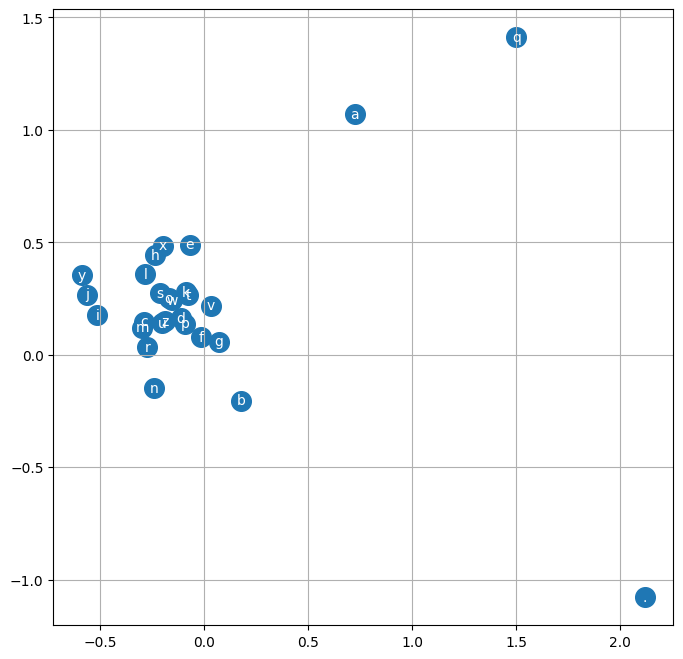

In [325]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [327]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(100):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

mora.
kayah.
seel.
nihahal.
rethanield.
len.
azeredieli.
jeli.
jelle.
elioana.
artell.
kostter.
noshur.
rishiane.
tricke.
jelionnterian.
breyce.
ryylani.
eliya.
ajmyan.
yamihia.
salynn.
ulizaj.
leeu.
elli.
tris.
jaisley.
adilfhy.
oyobh.
gpei.
joretty.
chhirar.
jina.
iri.
evpanwrlan.
ortarli.
tane.
sila.
brityn.
debilin.
dameliane.
arriy.
xavi.
fhamaizenicka.
imoahd.
aive.
dihivirle.
ajalena.
mooag.
ricta.
iiai.
glon.
ellahanylon.
jairy.
noge.
makir.
keshon.
mecie.
nailee.
jaes.
ama.
coper.
tyleigb.
emoera.
laseich.
haele.
kagoritlior.
caleko.
acofeltn.
nakdahari.
kennat.
resson.
sansa.
ascell.
cilynancah.
diel.
mayana.
lakaan.
emman.
luhiah.
soloigh.
kalyi.
alejune.
trayline.
jafiia.
tomeri.
emoreiza.
adyla.
quin.
zevane.
bariah.
athlyn.
cidi.
beeas.
riy.
nallas.
xearto.
yumasi.
jamletci.
selen.
